In [ ]:

!pip install -q kagglehub

import os
import kagglehub
import shutil

os.environ['KAGGLE_API_TOKEN'] = 'KGAT_9fdaa25ebe455e672e0bce98c601666c'

print("Downloading MRI Dataset using KaggleHub...")
cache_path = kagglehub.dataset_download("masoudnickparvar/brain-tumor-mri-dataset")

destination_path = "/content/brain_tumor_dataset"
shutil.copytree(cache_path, destination_path, dirs_exist_ok=True)

print(f"\nSuccess! Dataset is ready and sitting in: {destination_path}")

Using Colab cache for faster access to the 'brain-tumor-mri-dataset' dataset.

Success! Dataset is ready and sitting in: /content/brain_tumor_dataset


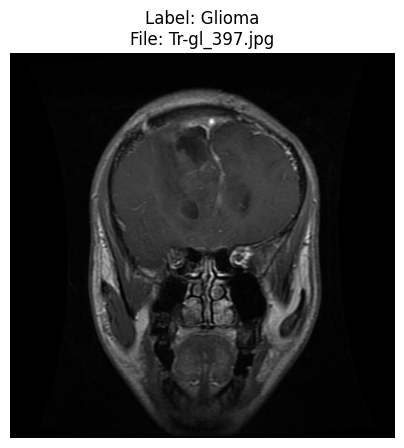

The computer sees this image as a grid of numbers with shape: (512, 512)


In [ ]:
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

dataset_path = "/content/brain_tumor_dataset"
glioma_folder = os.path.join(dataset_path, "Training", "glioma")

all_glioma_images = os.listdir(glioma_folder)
first_image_name = all_glioma_images[0]
first_image_path = os.path.join(glioma_folder, first_image_name)

img = mpimg.imread(first_image_path)


plt.figure(figsize=(5, 5))
plt.imshow(img, cmap='gray')
plt.title(f"Label: Glioma\nFile: {first_image_name}")
plt.axis('off')
plt.show()

print(f"The computer sees this image as a grid of numbers with shape: {img.shape}")

In [ ]:
import tensorflow as tf

batch_size = 32
img_height = 224
img_width = 224
dataset_path = "/content/brain_tumor_dataset"

print("Setting up Training Pipeline:")
train_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path + "/Training",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode='grayscale'
)

print("\nSetting up Testing Pipeline:")
test_ds = tf.keras.utils.image_dataset_from_directory(
  dataset_path + "/Testing",
  seed=123,
  image_size=(img_height, img_width),
  batch_size=batch_size,
  color_mode='grayscale'
)

normalization_layer = tf.keras.layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y))
test_ds = test_ds.map(lambda x, y: (normalization_layer(x), y))

print("\nData pipeline successfully built and standardized!")

Setting up Training Pipeline:
Found 5600 files belonging to 4 classes.

Setting up Testing Pipeline:
Found 1600 files belonging to 4 classes.

Data pipeline successfully built and standardized!


In [ ]:
from tensorflow.keras import layers, models

model = models.Sequential()

# Layer 1:basic edges 32bit
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 1)))
model.add(layers.MaxPooling2D((2, 2)))

# Layer 2:complex patterns 64bit
model.add(layers.Conv2D(64, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# Layer 3: high-level structures 128bit
model.add(layers.Conv2D(128, (3, 3), activation='relu'))
model.add(layers.MaxPooling2D((2, 2)))

# 2D to 1D
model.add(layers.Flatten())

#prise de decision
model.add(layers.Dense(128, activation='relu'))

#neurons for our 4 specific classes
model.add(layers.Dense(4, activation='softmax'))

# compilation
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Printing the model
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │    11,075,712 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,168,900 (42.61 MB)

 Trainable params: 11,168,900 (42.61 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
#introduction of the training data

print("Starting the training process... (This will take a few minutes using your T4 GPU)")

history = model.fit(
  train_ds,
  validation_data=test_ds,
  epochs=5
)

print("\nTraining complete!")

Starting the training process... (This will take a few minutes using your T4 GPU)
Epoch 1/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 20s 65ms/step - accuracy: 0.7248 - loss: 0.6689 - val_accuracy: 0.7481 - val_loss: 1.0029
Epoch 2/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.8857 - loss: 0.3085 - val_accuracy: 0.8331 - val_loss: 0.6970
Epoch 3/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.9430 - loss: 0.1615 - val_accuracy: 0.8556 - val_loss: 0.8616
Epoch 4/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 64ms/step - accuracy: 0.9657 - loss: 0.1008 - val_accuracy: 0.8544 - val_loss: 1.1401
Epoch 5/5
175/175 ━━━━━━━━━━━━━━━━━━━━ 19s 59ms/step - accuracy: 0.9811 - loss: 0.0535 - val_accuracy: 0.8813 - val_loss: 1.0240

Training complete!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# taking one eg of the test data
for images, labels in test_ds.take(1):

    # taking first image with no labels
    sample_image = images[0]
    true_label_index = labels[0].numpy()

    # batching data
    image_for_ai = tf.expand_dims(sample_image, 0)

    # prediction
    prediction_scores = model.predict(image_for_ai)

    # highest score finder
    predicted_index = np.argmax(prediction_scores[0])
    confidence = np.max(prediction_scores[0]) * 100

    # classes
    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
    true_diagnosis = class_names[true_label_index]
    ai_diagnosis = class_names[predicted_index]

    # the MRI image
    plt.figure(figsize=(6, 6))
    plt.imshow(sample_image.numpy().squeeze(), cmap='gray')

    # coloring the results
    color = 'green' if true_diagnosis == ai_diagnosis else 'red'

    plt.title(f"Actual Scan: {true_diagnosis}\nAI Diagnosis: {ai_diagnosis} ({confidence:.2f}% sure)", color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

In [ ]:
# saving
model.save('my_first_brain_tumor_model.keras')

print("Model successfully saved to your Colab files!")

Model successfully saved to your Colab files!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# taking one eg of the test data
for images, labels in test_ds.take(1):

    # taking first image with no labels
    sample_image = images[0]
    true_label_index = labels[0].numpy()

    # batching data
    image_for_ai = tf.expand_dims(sample_image, 0)

    # prediction
    prediction_scores = model.predict(image_for_ai)

    # highest score finder
    predicted_index = np.argmax(prediction_scores[0])
    confidence = np.max(prediction_scores[0]) * 100

    # classes
    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
    true_diagnosis = class_names[true_label_index]
    ai_diagnosis = class_names[predicted_index]

    # the MRI image
    plt.figure(figsize=(6, 6))
    plt.imshow(sample_image.numpy().squeeze(), cmap='gray')

    # coloring the results
    color = 'green' if true_diagnosis == ai_diagnosis else 'red'

    plt.title(f"Actual Scan: {true_diagnosis}\nAI Diagnosis: {ai_diagnosis} ({confidence:.2f}% sure)", color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


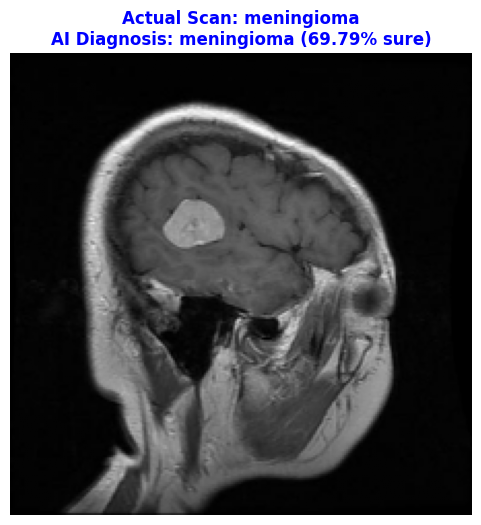

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# taking one eg of the test data
for images, labels in test_ds.take(1):

    # taking first image with no labels
    sample_image = images[0]
    true_label_index = labels[0].numpy()

    # batching data
    image_for_ai = tf.expand_dims(sample_image, 0)

    # prediction
    prediction_scores = model.predict(image_for_ai)

    # highest score finder
    predicted_index = np.argmax(prediction_scores[0])
    confidence = np.max(prediction_scores[0]) * 100

    # classes
    class_names = ['glioma', 'meningioma', 'notumor', 'pituitary']
    true_diagnosis = class_names[true_label_index]
    ai_diagnosis = class_names[predicted_index]

    # the MRI image
    plt.figure(figsize=(6, 6))
    plt.imshow(sample_image.numpy().squeeze(), cmap='gray')

    # coloring the results
    color = 'green' if true_diagnosis == ai_diagnosis else 'red'

    plt.title(f"Actual Scan: {true_diagnosis}\nAI Diagnosis: {ai_diagnosis} ({confidence:.2f}% sure)", color=color, fontweight='bold')
    plt.axis('off')
    plt.show()

In [ ]:
from google.colab import files

# Trigger the download directly to your local computer
files.download('my_first_brain_tumor_model.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from tensorflow.keras import layers, models

# Model V2
model_v2 = models.Sequential()

#flip and rotation
model_v2.add(layers.RandomFlip("horizontal", input_shape=(224, 224, 1)))
model_v2.add(layers.RandomRotation(0.1))

# layers like first code
model_v2.add(layers.Conv2D(32, (3, 3), activation='relu'))
model_v2.add(layers.MaxPooling2D((2, 2)))

model_v2.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_v2.add(layers.MaxPooling2D((2, 2)))

model_v2.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_v2.add(layers.MaxPooling2D((2, 2)))

# TRANSITION
model_v2.add(layers.Flatten())

# 50% layers dropout
model_v2.add(layers.Dropout(0.5))

# DECISION MAKING
model_v2.add(layers.Dense(128, activation='relu'))
model_v2.add(layers.Dense(4, activation='softmax'))

# Compilation
model_v2.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

print("Model V2 built with Dropout and Data Augmentation!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model V2 built with Dropout and Data Augmentation!


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping

#early stopping recalling
early_stopper = EarlyStopping(
    monitor='val_loss',    #watched value
    patience=3,        #3 epochs max watch
    restore_best_weights=True   #back to the best
)

print("Starting smart training with Early Stopping! (Max 50 Epochs)")

# training along callback
history_v3 = model_v2.fit(
  train_ds,
  validation_data=test_ds,
  epochs=50,
  callbacks=[early_stopper]
)

print("\nSmart Training complete! The AI automatically kept the best weights.")

Starting smart training with Early Stopping! (Max 50 Epochs)
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 59ms/step - accuracy: 0.6498 - loss: 0.8499 - val_accuracy: 0.6556 - val_loss: 1.2173
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 17s 66ms/step - accuracy: 0.7925 - loss: 0.5450 - val_accuracy: 0.7131 - val_loss: 0.9817
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.8205 - loss: 0.4559 - val_accuracy: 0.7462 - val_loss: 0.9755
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 61ms/step - accuracy: 0.8604 - loss: 0.3725 - val_accuracy: 0.7875 - val_loss: 0.9042
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.8739 - loss: 0.3259 - val_accuracy: 0.7944 - val_loss: 0.8610
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 58ms/step - accuracy: 0.8895 - loss: 0.2912 - val_accuracy: 0.8050 - val_loss: 0.8663
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step - accuracy: 0.8945 - loss: 0.2689 - val_accuracy: 0.8338 - val_loss: 0.9463
Epoch 8/50
175/175 ━━━━━━━━━━

Gathering 1,600 predictions for the Confusion Matrix... (This might take a few seconds)


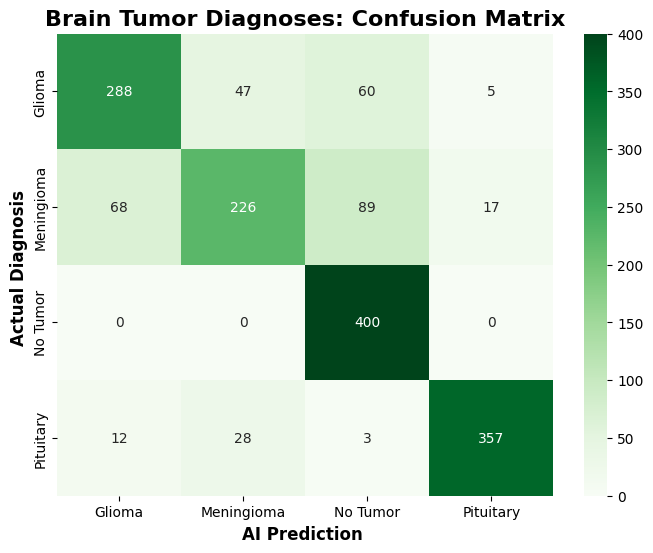

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Gathering 1,600 predictions for the Confusion Matrix... (This might take a few seconds)")

true_labels = []
ai_predictions = []

for images, labels in test_ds:
    true_labels.extend(labels.numpy())

    batch_predictions = model_v2.predict(images, verbose=0)

    batch_predicted_labels = np.argmax(batch_predictions, axis=1)
    ai_predictions.extend(batch_predicted_labels)

cm = confusion_matrix(true_labels, ai_predictions)

class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('Brain Tumor Diagnoses: Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Diagnosis ', fontsize=12, fontweight='bold')
plt.xlabel('AI Prediction ', fontsize=12, fontweight='bold')
plt.show()


In [ ]:
from tensorflow.keras import layers, models
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# enhanced data augmentation with zoom
data_augmentation = models.Sequential([
    layers.RandomFlip("horizontal", input_shape=(224, 224, 1)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
])

#build v3 architecture
model_v3 = models.Sequential()
model_v3.add(data_augmentation)

# block 1: 32 filters
model_v3.add(layers.Conv2D(32, (3, 3), activation='relu'))
model_v3.add(layers.BatchNormalization()) #stabilize learning
model_v3.add(layers.MaxPooling2D((2, 2)))

#block 2: 64 filters
model_v3.add(layers.Conv2D(64, (3, 3), activation='relu'))
model_v3.add(layers.BatchNormalization())
model_v3.add(layers.MaxPooling2D((2, 2)))

#block 3: 128 filters
model_v3.add(layers.Conv2D(128, (3, 3), activation='relu'))
model_v3.add(layers.BatchNormalization())
model_v3.add(layers.MaxPooling2D((2, 2)))

#block 4: 256 filters
model_v3.add(layers.Conv2D(256, (3, 3), activation='relu'))
model_v3.add(layers.BatchNormalization())
model_v3.add(layers.MaxPooling2D((2, 2)))

# fully connected layers
model_v3.add(layers.Flatten())
model_v3.add(layers.Dropout(0.5))

model_v3.add(layers.Dense(256, activation='relu'))
model_v3.add(layers.BatchNormalization())
model_v3.add(layers.Dropout(0.3)) #secondary dropout

model_v3.add(layers.Dense(4, activation='softmax'))

model_v3.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
print("v3 model built!")

/usr/local/lib/python3.12/dist-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


V3 Pro Model built with Batch Norm and Deep Extractors!


In [ ]:
early_stopper = EarlyStopping(monitor='val_loss', patience=6, restore_best_weights=True)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=0.00001, verbose=1)
print("Starting V3 Training... Watch the dynamic learning rate in action!")

#train
history_v3 = model_v3.fit(
  train_ds,
  validation_data=test_ds,
  epochs=50,
  callbacks=[early_stopper, lr_reducer]
)

print("\nV3 Training Complete! Best weights restored.")

Starting V3 Training... Watch the dynamic learning rate in action!
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 127ms/step - accuracy: 0.7232 - loss: 0.7954 - val_accuracy: 0.2500 - val_loss: 5.3389 - learning_rate: 0.0010
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - accuracy: 0.7989 - loss: 0.5361 - val_accuracy: 0.4638 - val_loss: 2.4559 - learning_rate: 0.0010
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 134ms/step - accuracy: 0.8275 - loss: 0.4604 - val_accuracy: 0.6413 - val_loss: 1.0800 - learning_rate: 0.0010
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 22s 127ms/step - accuracy: 0.8388 - loss: 0.4286 - val_accuracy: 0.6731 - val_loss: 1.8186 - learning_rate: 0.0010
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 23s 130ms/step - accuracy: 0.8650 - loss: 0.3604 - val_accuracy: 0.8012 - val_loss: 0.8713 - learning_rate: 0.0010
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.8825 - loss: 0.3184 - val_accuracy: 0.6750 - val_loss: 1.8764 - learning_rate: 0.0010
Epo

In [ ]:
model_v3.save('brain_tumor_v3_PRO.keras')
from google.colab import files
files.download('brain_tumor_v3_PRO.keras')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Gathering 1,600 predictions for the V3 PRO Confusion Matrix... (This might take a few seconds)


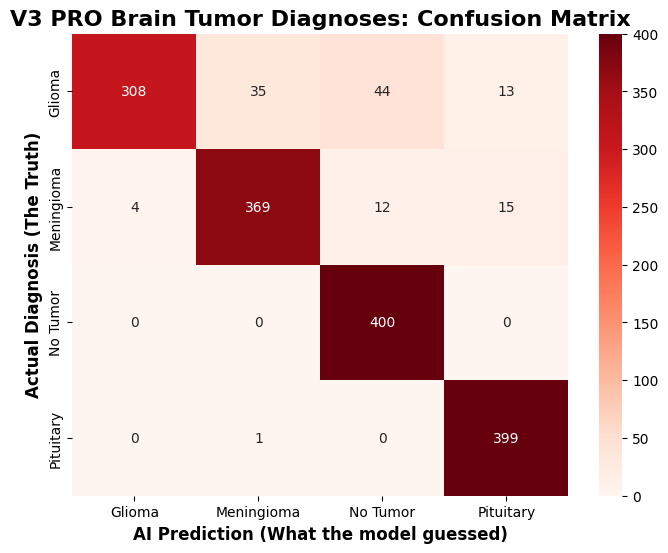

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

print("Gathering 1,600 predictions for the V3 PRO Confusion Matrix... (This might take a few seconds)")

true_labels = []
ai_predictions = []


for images, labels in test_ds:

    true_labels.extend(labels.numpy())

    batch_predictions = model_v3.predict(images, verbose=0)

    batch_predicted_labels = np.argmax(batch_predictions, axis=1)
    ai_predictions.extend(batch_predicted_labels)

cm = confusion_matrix(true_labels, ai_predictions)

class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds',
            xticklabels=class_names,
            yticklabels=class_names)

plt.title('V3 PRO Brain Tumor Diagnoses: Confusion Matrix', fontsize=16, fontweight='bold')
plt.ylabel('Actual Diagnosis (The Truth)', fontsize=12, fontweight='bold')
plt.xlabel('AI Prediction (What the model guessed)', fontsize=12, fontweight='bold')
plt.show()

Please upload a brain MRI scan from your computer:


Saving healthy brain MRI.jpeg to healthy brain MRI.jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 358ms/step


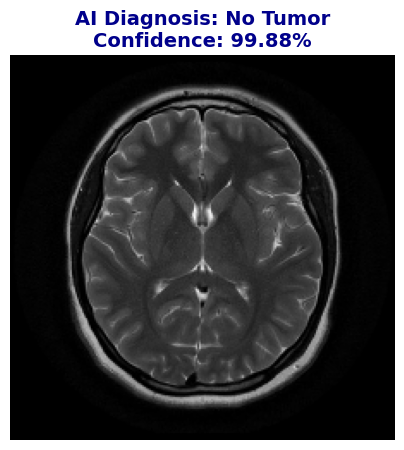

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files

print("Please upload a brain MRI scan from your computer:")
uploaded = files.upload()

# process uploaded image
for file_name in uploaded.keys():
    # load and resize grayscale image
    img = tf.keras.utils.load_img(file_name, target_size=(224, 224), color_mode="grayscale")

    # convert to array and scale pixels
    img_array = tf.keras.utils.img_to_array(img) / 255.0

    # add batch dimension
    img_array = tf.expand_dims(img_array, 0)

    # predict using model
    predictions = model_v3.predict(img_array)
    confidence = np.max(predictions[0]) * 100
    predicted_index = np.argmax(predictions[0])

    #map to class names
    class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
    diagnosis = class_names[predicted_index]

    # display result
    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(f"AI Diagnosis: {diagnosis}\nConfidence: {confidence:.2f}%",
              fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()

Please upload a brain MRI scan from your computer:


Saving meningioma brain MRI.jpeg to meningioma brain MRI (2).jpeg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


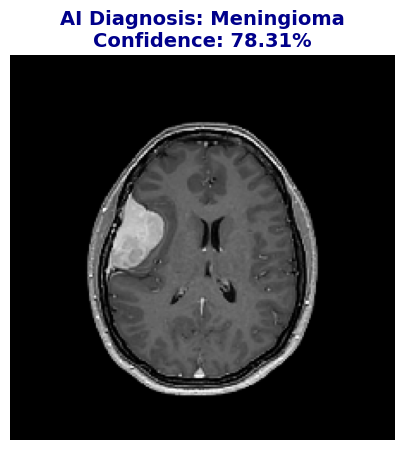

In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
from google.colab import files

print("Please upload a brain MRI scan from your computer:")
uploaded = files.upload()

for file_name in uploaded.keys():
   #greying and rescaling
    img = tf.keras.utils.load_img(file_name, target_size=(224, 224), color_mode="grayscale")
    img_array = tf.keras.utils.img_to_array(img) / 255.0
    img_array = tf.expand_dims(img_array, 0)

    predictions = model_v3.predict(img_array)
    confidence = np.max(predictions[0]) * 100
    predicted_index = np.argmax(predictions[0])

    class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']
    diagnosis = class_names[predicted_index]

    plt.figure(figsize=(5, 5))
    plt.imshow(img, cmap='gray')
    plt.title(f"AI Diagnosis: {diagnosis}\nConfidence: {confidence:.2f}%",
              fontsize=14, fontweight='bold', color='darkblue')
    plt.axis('off')
    plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("Building the V4 'Tough Love' Model...")

data_augmentation = tf.keras.Sequential([
  layers.RandomFlip("horizontal_and_vertical"),
  layers.RandomRotation(0.1),
  layers.RandomContrast(0.2),
  layers.RandomBrightness(0.2),
])

model_v4 = models.Sequential([
    layers.InputLayer(input_shape=(224, 224, 1)),

    data_augmentation,

    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

model_v4.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

#early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True,
    verbose=1
)

print("V4 Model Ready! Starting training with Early Stopping...")

#training
history_v4 = model_v4.fit(
  train_ds,
  validation_data=test_ds,
  epochs=50,
  callbacks=[early_stopping]
)

Building the V4 'Tough Love' Model...
V4 Model Ready! Starting training with Early Stopping...
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - accuracy: 0.2384 - loss: 2.9749 - val_accuracy: 0.2438 - val_loss: 1.3859
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 65ms/step - accuracy: 0.2480 - loss: 1.3895 - val_accuracy: 0.2637 - val_loss: 1.3839
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.2463 - loss: 1.4087 - val_accuracy: 0.3019 - val_loss: 1.3819
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.2361 - loss: 1.4016 - val_accuracy: 0.2812 - val_loss: 1.3772
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 12s 67ms/step - accuracy: 0.2471 - loss: 1.3864 - val_accuracy: 0.3000 - val_loss: 1.3711
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - accuracy: 0.2432 - loss: 1.3859 - val_accuracy: 0.2944 - val_loss: 1.8268
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 11s 62ms/step - accuracy: 0.2575 - loss: 1.6080 - val_accuracy: 0.2919 - val_loss: 1.

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models

print("building the V4 PRO model...")

# data augmentation
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.05),
    layers.RandomContrast(0.1),
])

# build model architecture
model_v4 = models.Sequential([
    layers.InputLayer(input_shape=(224, 224, 1)),

    # scale pixels to 0-1
    layers.Rescaling(1./255),

    data_augmentation,

    # cnn layers with batch normalization
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),

    # fully connected layers
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(4, activation='softmax')
])

# compile model
model_v4.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# early stopping callback
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True,
    verbose=1
)

# learning rate scheduler callback
lr_scheduler = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    min_lr=1e-6,
    verbose=1
)

print("starting training with callbacks...")

#training
history_v4 = model_v4.fit(
    train_ds,
    validation_data=test_ds,
    epochs=50,
    callbacks=[early_stopping, lr_scheduler]
)

Building the V4.1 'Firm but Fair' Model...
V4.1 Model Ready! Starting training...
Epoch 1/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 27s 128ms/step - accuracy: 0.5905 - loss: 1.5311 - val_accuracy: 0.2500 - val_loss: 2.3627
Epoch 2/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 120ms/step - accuracy: 0.7102 - loss: 0.7157 - val_accuracy: 0.2500 - val_loss: 4.0252
Epoch 3/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - accuracy: 0.7382 - loss: 0.6451 - val_accuracy: 0.2500 - val_loss: 5.0127
Epoch 4/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 122ms/step - accuracy: 0.7759 - loss: 0.5650 - val_accuracy: 0.3994 - val_loss: 3.0390
Epoch 5/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - accuracy: 0.7829 - loss: 0.5621 - val_accuracy: 0.4431 - val_loss: 1.7141
Epoch 6/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 21s 121ms/step - accuracy: 0.8073 - loss: 0.4930 - val_accuracy: 0.2500 - val_loss: 10.3417
Epoch 7/50
175/175 ━━━━━━━━━━━━━━━━━━━━ 42s 126ms/step - accuracy: 0.8213 - loss: 0.4783 - val_accuracy: 0.6712 - val_loss: 1.3860


In [ ]:

model_v4.save('brain_tumor_v4_PRO.keras')
print("V4 PRO Brain Saved Successfully! Ready for download.")


V4 PRO Brain Saved Successfully! Ready for download.


Gathering predictions for the V4 PRO Confusion Matrix...


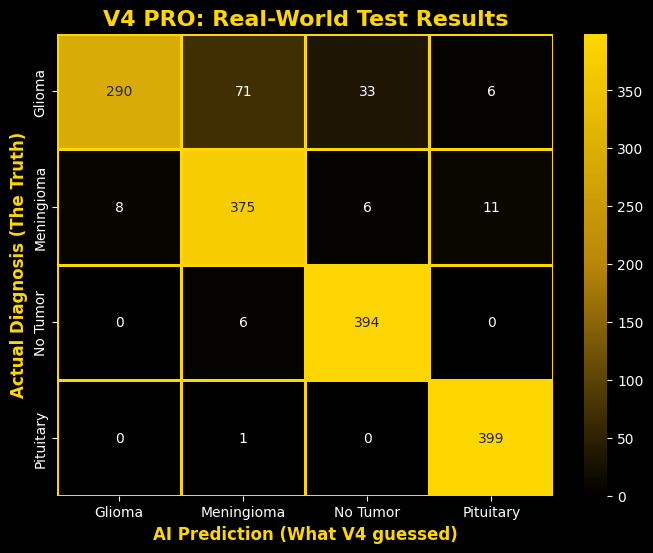

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from matplotlib.colors import LinearSegmentedColormap

print("gathering predictions for v4 pro confusion matrix...")

true_labels = []
ai_predictions = []

# iterate through testing dataset
for images, labels in test_ds:
    # save true labels
    true_labels.extend(labels.numpy())

    # get model predictions
    batch_predictions = model_v4.predict(images, verbose=0)

    # convert probabilities to classes
    batch_predicted_labels = np.argmax(batch_predictions, axis=1)
    ai_predictions.extend(batch_predicted_labels)

# calculate confusion matrix
cm = confusion_matrix(true_labels, ai_predictions)

# custom black and gold palette
colors = ["#000000", "#B8860B", "#FFD700"]
black_gold_cmap = LinearSegmentedColormap.from_list("black_gold", colors)

# plot in dark mode
class_names = ['Glioma', 'Meningioma', 'No Tumor', 'Pituitary']

plt.style.use('dark_background')
plt.figure(figsize=(8, 6))

# draw heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap=black_gold_cmap,
            xticklabels=class_names,
            yticklabels=class_names,
            linewidths=1, linecolor='#FFD700')

plt.title('V4 PRO: Real-World Test Results', fontsize=16, fontweight='bold', color='#FFD700')
plt.ylabel('Actual Diagnosis', fontsize=12, fontweight='bold', color='#FFD700')
plt.xlabel('AI Prediction', fontsize=12, fontweight='bold', color='#FFD700')

plt.show()

# reset plot style
plt.style.use('default')